# 01 毕业生供给侧分析

本 notebook 基于 `data/processed/graduate_supply_panel.csv`，分析 2011-2025 年高校毕业生供给变化。

重点输出三张图：

1. 高校毕业生总量趋势
2. 研究生毕业生规模趋势
3. 研究生毕业生占比趋势

口径说明：`graduate_total = 普通本科、专科生毕(结)业生数 + 研究生毕(结)业生数`。2025 年硕士和博士分项在原始表中缺失，因此硕士/博士拆分图表暂时只解释到 2024 年。

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import FuncFormatter
import pandas as pd

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "graduate_supply_panel.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig").sort_values("year")
df.tail()

,year,graduate_total,undergraduate_vocational_graduates,undergraduate_graduates,vocational_graduates,postgraduate_graduates,master_graduates,doctoral_graduates,postgraduate_share,master_share,unit,data_scope,source,source_file,note
10,2021,903.7761,826.5,428.0970,398.4,77.2761,70.0742,7.2019,0.085504,0.077535,万人,年度统计口径,教育-年度数据.xlsx,data/raw/official_statistics/教育-年度数据.xlsx,graduate_total=普通本科、专科生毕(结)业生数+研究生毕(结)业生数
11,2022,1053.5165,967.3,471.5658,494.8,86.2165,77.9845,8.2320,0.081837,0.074023,万人,年度统计口径,教育-年度数据.xlsx,data/raw/official_statistics/教育-年度数据.xlsx,graduate_total=普通本科、专科生毕(结)业生数+研究生毕(结)业生数
12,2023,1148.4755,1047.0,489.7422,553.3,101.4755,92.7629,8.7126,0.088357,0.080770,万人,年度统计口径,教育-年度数据.xlsx,data/raw/official_statistics/教育-年度数据.xlsx,graduate_total=普通本科、专科生毕(结)业生数+研究生毕(结)业生数
13,2024,1167.7595,1059.4,511.9577,540.4,108.3595,98.6410,9.7185,0.092793,0.084470,万人,年度统计口径,教育-年度数据.xlsx,data/raw/official_statistics/教育-年度数据.xlsx,graduate_total=普通本科、专科生毕(结)业生数+研究生毕(结)业生数
14,2025,1221.8000,1105.1,NaN,NaN,116.7000,NaN,NaN,0.095515,NaN,万人,年度统计口径,教育-年度数据.xlsx,data/raw/official_statistics/教育-年度数据.xlsx,graduate_total=普通本科、专科生毕(结)业生数+研究生毕(结)业生数；硕士/博...


In [2]:
def set_chinese_font():
    candidates = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "Arial Unicode MS",
    ]
    available = {
        font_manager.FontProperties(fname=font_path).get_name()
        for font_path in font_manager.findSystemFonts()
    }
    for candidate in candidates:
        if candidate in available:
            plt.rcParams["font.sans-serif"] = [candidate, "DejaVu Sans"]
            break
    plt.rcParams["axes.unicode_minus"] = False


set_chinese_font()

COLORS = {
    "ink": "#202124",
    "muted": "#6B7280",
    "grid": "#E5E7EB",
    "paper": "#FAFAF7",
    "accent": "#D9480F",
    "blue": "#1F6F8B",
    "green": "#2E7D32",
}


def setup_figure(figsize=(11, 6.2)):
    fig, ax = plt.subplots(figsize=figsize, dpi=160)
    fig.patch.set_facecolor(COLORS["paper"])
    ax.set_facecolor(COLORS["paper"])
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#D1D5DB")
    ax.grid(axis="y", color=COLORS["grid"], linewidth=0.9)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="both", colors=COLORS["muted"], labelsize=10)
    return fig, ax


def add_title(ax, title, subtitle):
    ax.text(
        0,
        1.12,
        title,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=20,
        fontweight="bold",
        color=COLORS["ink"],
    )
    ax.text(
        0,
        1.055,
        subtitle,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=11,
        color=COLORS["muted"],
    )


def add_source(ax):
    ax.text(
        0,
        -0.18,
        "数据来源：国家统计局；单位：万人；高校毕业生总量=普通本专科毕(结)业生+研究生毕(结)业生",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        color=COLORS["muted"],
    )


def annotate_endpoint(ax, x, y, label, color):
    ax.scatter([x], [y], s=54, color=color, edgecolor="white", linewidth=1.5, zorder=5)
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(10, 8),
        textcoords="offset points",
        fontsize=10.5,
        color=color,
        fontweight="bold",
    )


def pct_axis(x, _):
    return f"{x:.0%}"

In [3]:
def growth_between(data, column, start_year, end_year):
    start = data.loc[data["year"] == start_year, column].iloc[0]
    end = data.loc[data["year"] == end_year, column].iloc[0]
    return end / start - 1


summary = pd.DataFrame(
    [
        {
            "指标": "高校毕业生总量",
            "2020": df.loc[df["year"] == 2020, "graduate_total"].iloc[0],
            "2025": df.loc[df["year"] == 2025, "graduate_total"].iloc[0],
            "2020-2025增幅": growth_between(df, "graduate_total", 2020, 2025),
        },
        {
            "指标": "研究生毕(结)业生数",
            "2020": df.loc[df["year"] == 2020, "postgraduate_graduates"].iloc[0],
            "2025": df.loc[df["year"] == 2025, "postgraduate_graduates"].iloc[0],
            "2020-2025增幅": growth_between(df, "postgraduate_graduates", 2020, 2025),
        },
        {
            "指标": "普通本专科毕(结)业生数",
            "2020": df.loc[df["year"] == 2020, "undergraduate_vocational_graduates"].iloc[0],
            "2025": df.loc[df["year"] == 2025, "undergraduate_vocational_graduates"].iloc[0],
            "2020-2025增幅": growth_between(df, "undergraduate_vocational_graduates", 2020, 2025),
        },
    ]
)

summary.style.format({"2020": "{:.1f}", "2025": "{:.1f}", "2020-2025增幅": "{:.1%}"})

,指标,2020,2025,2020-2025增幅
0,高校毕业生总量,870.1,1221.8,40.4%
1,研究生毕(结)业生数,72.9,116.7,60.2%
2,普通本专科毕(结)业生数,797.2,1105.1,38.6%


## 图 1：高校毕业生总量趋势

这一张图回答最基础的问题：进入就业市场的高校毕业生规模是否显著增加。

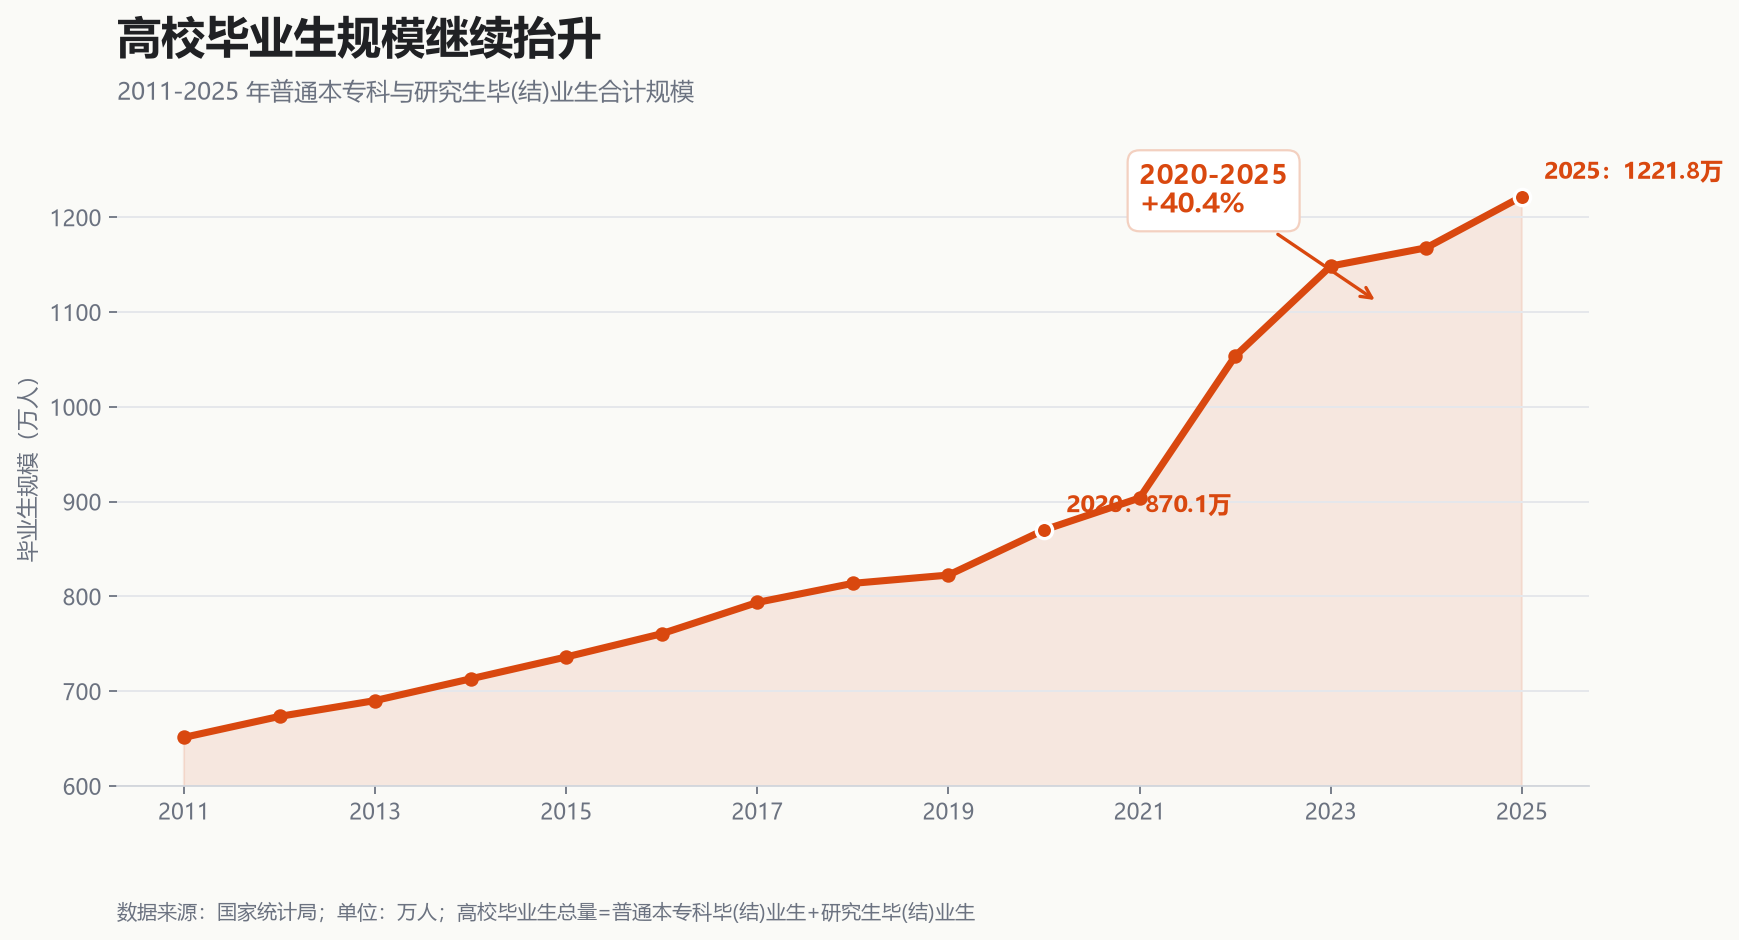

In [4]:
fig, ax = setup_figure()

ax.plot(
    df["year"],
    df["graduate_total"],
    color=COLORS["accent"],
    linewidth=3.2,
    marker="o",
    markersize=5.5,
)
ax.fill_between(df["year"], df["graduate_total"], color=COLORS["accent"], alpha=0.10)

add_title(
    ax,
    "高校毕业生规模继续抬升",
    "2011-2025 年普通本专科与研究生毕(结)业生合计规模",
)

value_2020 = df.loc[df["year"] == 2020, "graduate_total"].iloc[0]
value_2025 = df.loc[df["year"] == 2025, "graduate_total"].iloc[0]
growth = growth_between(df, "graduate_total", 2020, 2025)

annotate_endpoint(ax, 2020, value_2020, f"2020：{value_2020:.1f}万", COLORS["accent"])
annotate_endpoint(ax, 2025, value_2025, f"2025：{value_2025:.1f}万", COLORS["accent"])
ax.annotate(
    f"2020-2025\n+{growth:.1%}",
    xy=(2023.5, 1110),
    xytext=(2021.0, 1205),
    arrowprops=dict(arrowstyle="->", color=COLORS["accent"], lw=1.5),
    bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#F3D0C0", lw=1.0),
    fontsize=12,
    color=COLORS["accent"],
    fontweight="bold",
)

ax.set_ylabel("毕业生规模（万人）", color=COLORS["muted"])
ax.set_xticks(range(2011, 2026, 2))
ax.set_ylim(600, 1280)
add_source(ax)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "graduate_supply_trend.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## 图 2：研究生毕业生规模趋势

这一张图单独看研究生毕业供给。由于 2025 年硕士/博士分项缺失，硕士拆分线只画到 2024 年。

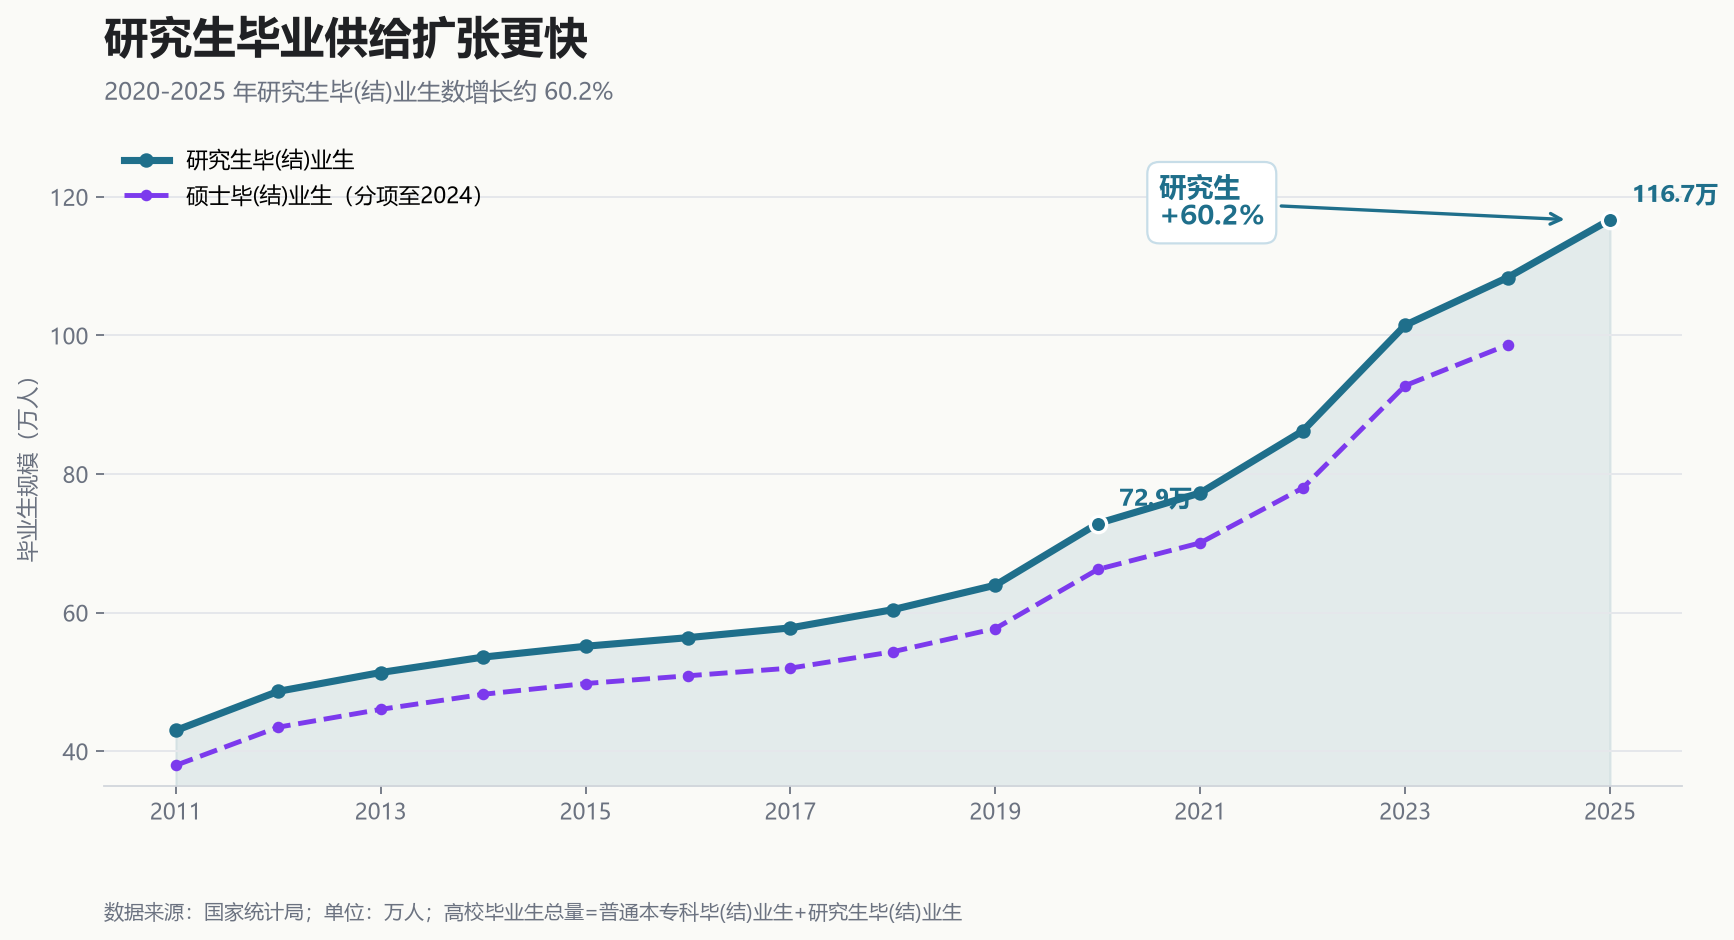

In [5]:
fig, ax = setup_figure()

ax.plot(
    df["year"],
    df["postgraduate_graduates"],
    color=COLORS["blue"],
    linewidth=3.2,
    marker="o",
    markersize=5.5,
    label="研究生毕(结)业生",
)
ax.fill_between(df["year"], df["postgraduate_graduates"], color=COLORS["blue"], alpha=0.10)

master_df = df.dropna(subset=["master_graduates"])
ax.plot(
    master_df["year"],
    master_df["master_graduates"],
    color="#7C3AED",
    linewidth=2.2,
    linestyle="--",
    marker="o",
    markersize=4.2,
    label="硕士毕(结)业生（分项至2024）",
)

add_title(
    ax,
    "研究生毕业供给扩张更快",
    "2020-2025 年研究生毕(结)业生数增长约 60.2%",
)

pg_2020 = df.loc[df["year"] == 2020, "postgraduate_graduates"].iloc[0]
pg_2025 = df.loc[df["year"] == 2025, "postgraduate_graduates"].iloc[0]
pg_growth = growth_between(df, "postgraduate_graduates", 2020, 2025)

annotate_endpoint(ax, 2020, pg_2020, f"{pg_2020:.1f}万", COLORS["blue"])
annotate_endpoint(ax, 2025, pg_2025, f"{pg_2025:.1f}万", COLORS["blue"])
ax.annotate(
    f"研究生\n+{pg_growth:.1%}",
    xy=(2024.6, pg_2025),
    xytext=(2020.6, 116),
    arrowprops=dict(arrowstyle="->", color=COLORS["blue"], lw=1.5),
    bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#C7DDE8", lw=1.0),
    fontsize=12,
    color=COLORS["blue"],
    fontweight="bold",
)

ax.set_ylabel("毕业生规模（万人）", color=COLORS["muted"])
ax.set_xticks(range(2011, 2026, 2))
ax.set_ylim(35, 128)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, 1.02), fontsize=10)
add_source(ax)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "postgraduate_supply_trend.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## 图 3：研究生毕业生占比趋势

这一张图观察学历结构是否上移：研究生毕业生在高校毕业生总量中的占比是否提高。

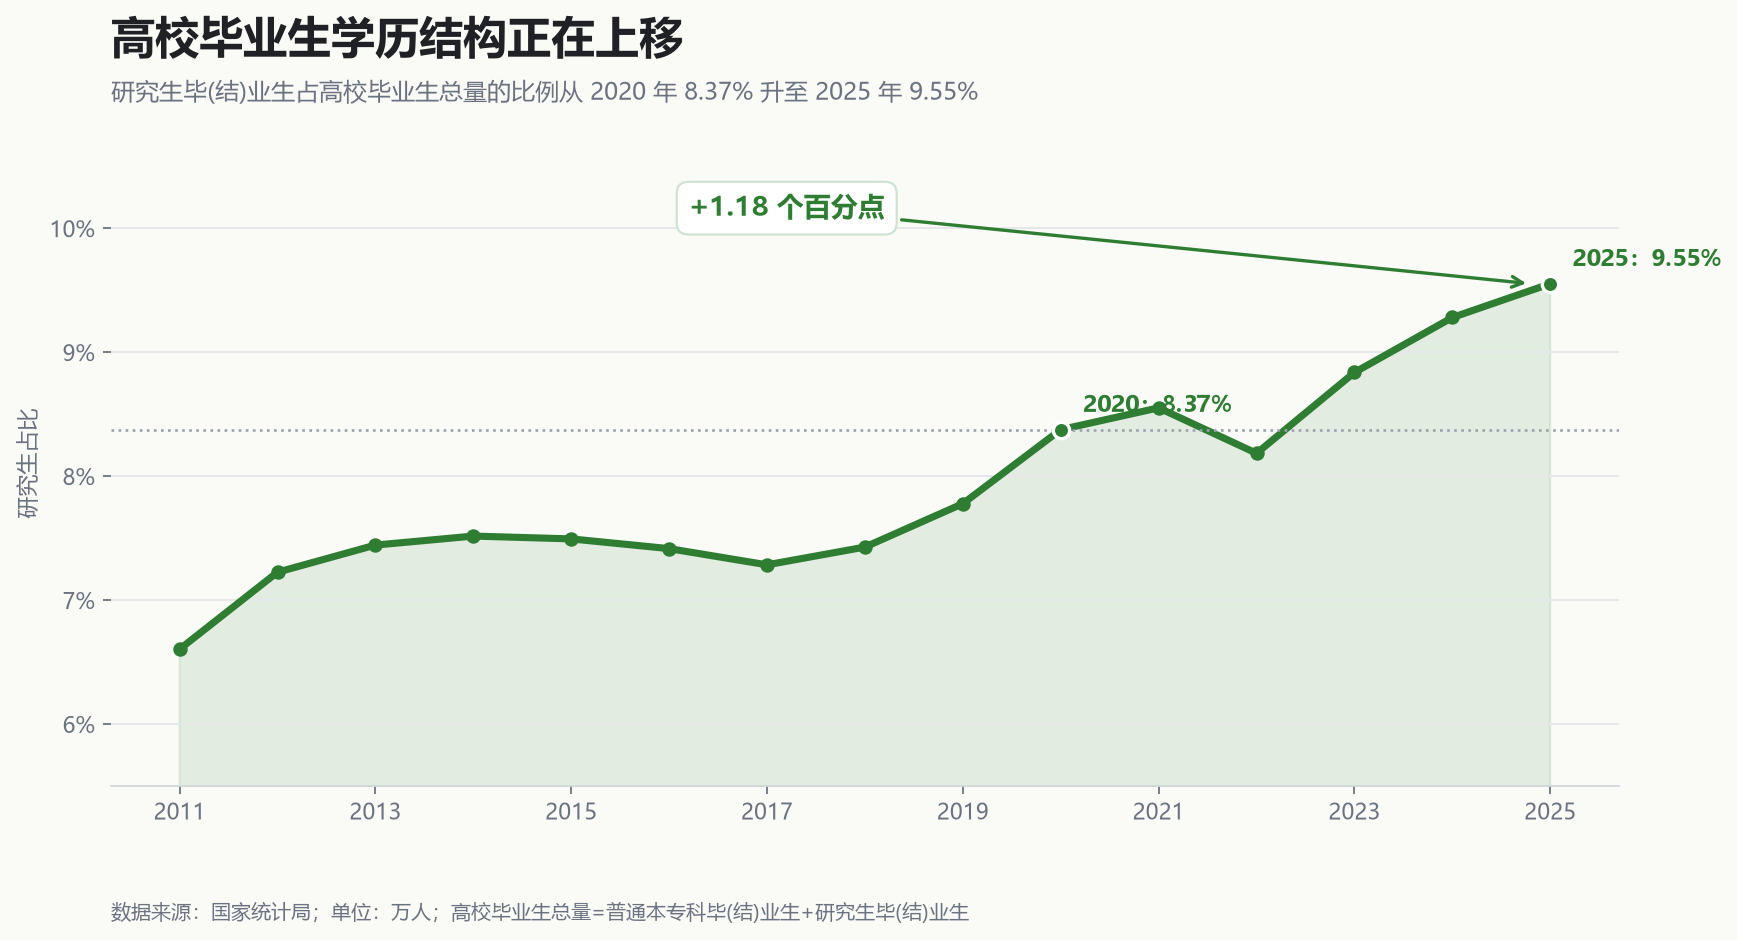

In [13]:
fig, ax = setup_figure()

ax.plot(
    df["year"],
    df["postgraduate_share"],
    color=COLORS["green"],
    linewidth=3.2,
    marker="o",
    markersize=5.5,
)
ax.fill_between(df["year"], df["postgraduate_share"], color=COLORS["green"], alpha=0.11)

add_title(
    ax,
    "高校毕业生学历结构正在上移",
    "研究生毕(结)业生占高校毕业生总量的比例从 2020 年 8.37% 升至 2025 年 9.55%",
)

share_2020 = df.loc[df["year"] == 2020, "postgraduate_share"].iloc[0]
share_2025 = df.loc[df["year"] == 2025, "postgraduate_share"].iloc[0]
annotate_endpoint(ax, 2020, share_2020, f"2020：{share_2020:.2%}", COLORS["green"])
annotate_endpoint(ax, 2025, share_2025, f"2025：{share_2025:.2%}", COLORS["green"])

ax.axhline(share_2020, color="#9CA3AF", linestyle=":", linewidth=1.2)
ax.annotate(
    f"+{(share_2025 - share_2020) * 100:.2f} 个百分点",
    xy=(2024.8, share_2025),
    xytext=(2016.2, 0.101),
    arrowprops=dict(arrowstyle="->", color=COLORS["green"], lw=1.5),
    bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#CFE3D1", lw=1.0),
    fontsize=12,
    color=COLORS["green"],
    fontweight="bold",
)

ax.yaxis.set_major_formatter(FuncFormatter(pct_axis))
ax.set_ylabel("研究生占比", color=COLORS["muted"])
ax.set_xticks(range(2011, 2026, 2))
ax.set_ylim(0.055, 0.107)
add_source(ax)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "postgraduate_share_trend.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## 初步发现

- 2020-2025 年，高校毕业生总量从约 870.1 万增加到 1221.8 万，增幅约 40.4%。
- 同期研究生毕(结)业生数从约 72.9 万增加到 116.7 万，增幅约 60.2%，快于普通本专科毕业生增幅。
- 研究生毕业生占比从 2020 年的 8.37% 提高到 2025 年的 9.55%，说明高校毕业生供给不仅总量增加，学历结构也在上移。

这些图表只能说明供给侧压力上升。是否转化为“更难就业”，还需要继续结合岗位需求侧和硕士岗位吸纳比分析。